# Superspreading Signature Detection

This notebook detects node-level superspreading signatures in a temporal cluster-transition network. Each node is a cluster of genetically close and temporally proximate SARS-CoV-2 sequences, defined in overlapping 3-week windows stepped forward by 1 week. Directed edges link clusters in adjacent windows and are weighted by the number of sequences shared between the source and target clusters.

The goal is not to prove that a specific exposure event occurred. Instead, the notebook labels network nodes whose local growth, onward continuity, downstream branching, geographic breadth, or demographic mixing look unusual relative to other nodes observed in the same time window.


## Method Rationale

The overlapping-window design intentionally allows the same sequence to appear in consecutive windows. When a sequence is present in two adjacent windows and its assigned cluster changes, that shared sequence provides evidence of continuity from one node to the next. Edge weights therefore measure observed overlap, not direct transmission counts.

The signature detection uses three complementary dimensions:

1. **Local amplification:** a node is large, novel relative to incoming overlap, or has high net amplification within its window or lifecycle stratum.
2. **Onward dissemination:** a node passes many shared sequences forward, branches into multiple successor nodes, or has an unusually even downstream distribution.
3. **Population mixing and spatial breadth:** a node contains more sex, age, SIMD, or health-board diversity than expected for its size and window, or spans unusually many data zones.

Censoring matters. Nodes at the beginning or end of the full dataset, or at the first/last window of a VOC epoch, have uncertain origins or onward spread. The categories retain those nodes but add a censoring note so they can be filtered during sensitivity checks.


## Setup

The notebook is designed to run from either the repository root or the `sse_detection/` folder. SSE-pipeline statistical helpers live in `sse_detection/lib/stats.py` (general helpers in `utils/stats.py`); notebook cells focus on orchestration and interpretation.


In [1]:
from collections import defaultdict
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "config.yaml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils import data as ld
from sse_detection.lib.stats import (
    add_sse_node_metrics,
    attach_entropy_zscore,
    categorise_sse_nodes,
    downstream_spread_entropy,
    flag_sse,
)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

RANDOM_SEED = 42
N_ENTROPY_DRAWS = 1000
N_DOWNSTREAM_PERMUTATIONS = 1000

## Load Sequence-Level Analysis Data

We read only the columns needed for node summaries, network construction, mixing scores, and contextual interpretation. The loader also attaches policy-period labels so candidate signatures can be reviewed against public-health context.


In [2]:
columns = [
    "window_id",
    "window_idx",
    "wn_mid_date",
    "cluster_id",
    "cluster_size",
    "cluster_n_datazones",
    "cluster_duration_days",
    "dz_health_board",
    "dz_local_authority",
    "datazone",
    "age_band",
    "sex",
    "dz_simd_quintile",
    "who_voc",
    "clade",
    "dz_7d_test_positivity",
    "wn_positive_tests",
    "wn_prop_sequenced",
    "dz_cum_sequences",
    "dz_cum_positive_tests",
    "dz_cum_prop_sequenced",
    "dz_cum_incidence_per_capita",
]

df_raw = ld.load_analysis_columns_pandas(columns, add_policy=True)

for date_col in ["collection_date", "wn_mid_date"]:
    df_raw[date_col] = pd.to_datetime(df_raw[date_col])

print(f"Sequence-window rows: {len(df_raw):,}")
print(f"Unique sequences: {df_raw['sequence_id'].nunique():,}")
print(f"Unique node-clusters: {df_raw['cluster_id'].nunique():,}")
print(f"Windows: {df_raw['window_idx'].min()} to {df_raw['window_idx'].max()}")

display(df_raw.head())

Sequence-window rows: 789,347
Unique sequences: 281,320
Unique node-clusters: 193,160
Windows: 1 to 134


,dz_cum_positive_tests,sequence_id,sex,cluster_n_datazones,age_band,datazone,dz_health_board,dz_cum_prop_sequenced,clade,wn_positive_tests,window_idx,cluster_size,collection_date,cluster_id,wn_mid_date,pango_lineage,dz_7d_test_positivity,dz_cum_sequences,resolution,nextclade_qc,dz_cum_incidence_per_capita,dz_local_authority,window_id,cluster_duration_days,who_voc,dz_simd_quintile,wn_prop_sequenced,policy_period,policy_period_label,policy_intensity
0,1.0,Scotland/CVR3946/2020,Female,1,45-49,S01007678,Dumfries and Galloway,1.0,20B,342.0,1,1,2020-07-04,W001|B.1.1.369|R0.3|S1,2020-07-14 12:00:00,B.1.1.369,0.022727,1.0,0.3,good,0.001350,Dumfries and Galloway,W001,0,NaN,2,0.184211,P2,Route map phase 2,52
1,1.0,Scotland/CVR3956/2020,Female,2,20-24,S01007643,Dumfries and Galloway,1.0,20B,422.0,2,3,2020-07-13,W002|B.1.1.369|R0.3|C2,2020-07-21 12:00:00,B.1.1.369,0.111111,1.0,0.3,good,0.001103,Dumfries and Galloway,W002,5,NaN,4,0.206161,P3,Route map phase 3,30
2,1.0,Scotland/CVR3956/2020,Female,2,20-24,S01007643,Dumfries and Galloway,1.0,20B,342.0,1,3,2020-07-13,W001|B.1.1.369|R0.3|C2,2020-07-14 12:00:00,B.1.1.369,0.111111,1.0,0.3,good,0.001103,Dumfries and Galloway,W001,5,NaN,4,0.184211,P3,Route map phase 3,30
3,1.0,Scotland/QEUH-94384C/2020,Male,1,35-39,S01011703,Lanarkshire,1.0,20B,342.0,1,1,2020-07-13,W001|B.1.1.10|R0.3|S0,2020-07-14 12:00:00,B.1.1.10,0.076923,1.0,0.3,good,0.001096,North Lanarkshire,W001,0,NaN,5,0.184211,P3,Route map phase 3,30
4,1.0,Scotland/QEUH-94384C/2020,Male,1,35-39,S01011703,Lanarkshire,1.0,20B,422.0,2,1,2020-07-13,W002|B.1.1.10|R0.3|S0,2020-07-21 12:00:00,B.1.1.10,0.076923,1.0,0.3,good,0.001096,North Lanarkshire,W002,0,NaN,5,0.206161,P3,Route map phase 3,30


## Null-Corrected Mixing Scores

Large clusters naturally contain more categories than small clusters. To avoid mistaking size for diversity, each entropy score is compared with a within-window null distribution: for each cluster size, categories are randomly drawn from the category frequencies observed in that same window. Positive z-scores indicate more mixing than expected for the cluster size and window.


In [3]:
ENTROPY_SPECS = [
    ("sex", "sex"),
    ("age_band", "age"),
    ("dz_simd_quintile", "simd"),
    ("dz_health_board", "health_board"),
]

for category_col, prefix in ENTROPY_SPECS:
    df_raw = attach_entropy_zscore(
        df=df_raw,
        cluster_col="cluster_id",
        category_col=category_col,
        window_col="window_id",
        n_random=N_ENTROPY_DRAWS,
        random_state=RANDOM_SEED,
        prefix=prefix,
    )

entropy_cols = [col for col in df_raw.columns if "entropy" in col]
print(f"Attached entropy columns: {len(entropy_cols)}")

Attached entropy columns: 16


## Collapse Rows to Node-Level Cluster Summaries

The raw analysis table is sequence-level, with one row per sequence-window observation. The network analysis needs one row per node-cluster. Summary fields use first/min/max values where the value is node-defined, and counts or modal values where the value is sequence-defined.


In [4]:
def join_top(values: pd.Series, n: int = 5) -> str:
    counts = values.dropna().astype(str).value_counts()
    return "; ".join(f"{name} ({count})" for name, count in counts.head(n).items())


def safe_mode(values: pd.Series):
    values = values.dropna()
    if values.empty:
        return np.nan
    return values.mode().iloc[0]


agg = {
    "cluster_size": ("cluster_size", "first"),
    "duration_days": ("cluster_duration_days", "first"),
    "cluster_n_datazones": ("cluster_n_datazones", "first"),
    "first_collection_date": ("collection_date", "min"),
    "last_collection_date": ("collection_date", "max"),
    "who_voc": ("who_voc", "first"),
    "clade": ("clade", "first"),
    "pango_lineage": ("pango_lineage", "first"),
    "policy_period": ("policy_period", safe_mode),
    "policy_periods": ("policy_period", "nunique"),
    "top_policy_periods": ("policy_period", join_top),
    "health_board": ("dz_health_board", safe_mode),
    "health_boards": ("dz_health_board", "nunique"),
    "top_health_boards": ("dz_health_board", join_top),
    "local_authority": ("dz_local_authority", safe_mode),
    "local_authorities": ("dz_local_authority", "nunique"),
    "top_local_authorities": ("dz_local_authority", join_top),
    "top_age_bands": ("age_band", join_top),
    "top_simd_quintiles": ("dz_simd_quintile", join_top),
    "dz_7d_test_positivity": ("dz_7d_test_positivity", "mean"),
    "dz_cum_sequences": ("dz_cum_sequences", "mean"),
    "dz_cum_incidence_per_capita": ("dz_cum_incidence_per_capita", "mean"),
    "dz_cum_positive_tests": ("dz_cum_positive_tests", "mean"),
    "dz_cum_prop_sequenced": ("dz_cum_prop_sequenced", "mean"),
    "wn_positive_tests": ("wn_positive_tests", "first"),
    "wn_prop_sequenced": ("wn_prop_sequenced", "first"),
    **{col: (col, "first") for col in entropy_cols},
}

cluster_table = (
    df_raw.groupby(["cluster_id", "window_id", "window_idx", "wn_mid_date"], as_index=False)
    .agg(**agg)
    .sort_values(["window_idx", "cluster_size"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"Node-clusters: {len(cluster_table):,}")
display(cluster_table.head())

Node-clusters: 193,160


,cluster_id,window_id,window_idx,wn_mid_date,cluster_size,duration_days,cluster_n_datazones,first_collection_date,last_collection_date,who_voc,clade,pango_lineage,policy_period,policy_periods,top_policy_periods,health_board,health_boards,top_health_boards,local_authority,local_authorities,top_local_authorities,top_age_bands,top_simd_quintiles,dz_7d_test_positivity,dz_cum_sequences,dz_cum_incidence_per_capita,dz_cum_positive_tests,dz_cum_prop_sequenced,wn_positive_tests,wn_prop_sequenced,sex_entropy_obs,sex_entropy_null_mean,sex_entropy_null_sd,sex_entropy_z,age_entropy_obs,age_entropy_null_mean,age_entropy_null_sd,age_entropy_z,simd_entropy_obs,simd_entropy_null_mean,simd_entropy_null_sd,simd_entropy_z,health_board_entropy_obs,health_board_entropy_null_mean,health_board_entropy_null_sd,health_board_entropy_z
0,W001|B.1.1.406|R0.3|C1,W001,1,2020-07-14 12:00:00,38,7,30,2020-07-17,2020-07-24,NaN,20B,B.1.1.406,P3,1,P3 (28),Lanarkshire,4,Lanarkshire (16); Greater Glasgow and Clyde (1...,North Lanarkshire,7,North Lanarkshire (11); South Lanarkshire (5);...,20-24 (5); 55-59 (4); 25-29 (4); 35-39 (4); 15...,2 (10); 3 (7); 1 (6); 4 (4); 5 (1),0.089309,1.214286,0.001792,1.392857,0.922619,342.0,0.184211,0.966619,0.948494,0.060704,0.298569,0.823584,0.766052,0.050273,1.144390,0.895583,0.927876,0.046981,-0.687361,0.35070,0.518183,0.055029,-3.043573
1,W001|B.1.1.369|R0.3|C2,W001,1,2020-07-14 12:00:00,3,5,2,2020-07-13,2020-07-18,NaN,20B,B.1.1.369,P3,1,P3 (3),Lothian,2,Lothian (2); Dumfries and Galloway (1),City of Edinburgh,2,City of Edinburgh (2); Dumfries and Galloway (1),25-29 (2); 20-24 (1),5 (2); 4 (1),0.214815,1.666667,0.003128,3.000000,0.666667,342.0,0.184211,0.918296,0.664846,0.410699,0.617118,0.229574,0.340130,0.087037,-1.270224,0.395488,0.509115,0.183071,-0.620673,0.24119,0.284557,0.118577,-0.365731
2,W001|B.1|R0.3|C1,W001,1,2020-07-14 12:00:00,3,2,1,2020-07-20,2020-07-22,NaN,20C,B.1,P3,1,P3 (3),Fife,1,Fife (3),Fife,1,Fife (3),35-39 (2); 30-34 (1),5 (3),0.166667,2.333333,0.002631,2.333333,1.000000,342.0,0.184211,0.918296,0.664846,0.410699,0.617118,0.229574,0.340130,0.087037,-1.270224,-0.000000,0.509115,0.183071,-2.780979,-0.00000,0.284557,0.118577,-2.399764
3,W001|B.1.36|R0.3|C1,W001,1,2020-07-14 12:00:00,2,0,1,2020-07-16,2020-07-16,NaN,20A,B.1.36,P3,1,P3 (2),Fife,1,Fife (2),Fife,1,Fife (2),40-44 (2),2 (2),0.166667,2.000000,0.003663,2.000000,1.000000,342.0,0.184211,1.000000,0.470000,0.499349,1.061382,-0.000000,0.223500,0.076998,-2.902676,-0.000000,0.336789,0.177910,-1.893032,-0.00000,0.185693,0.119602,-1.552597
4,W001|B.1|R0.3|C2,W001,1,2020-07-14 12:00:00,2,0,1,2020-07-22,2020-07-22,NaN,20A,B.1,P3,1,P3 (1),Greater Glasgow and Clyde,1,Greater Glasgow and Clyde (1),Glasgow City,1,Glasgow City (1),05-09 (1),4 (1),0.200000,2.000000,0.002780,3.000000,0.666667,342.0,0.184211,-0.000000,0.000000,0.000000,NaN,-0.000000,0.000000,0.000000,NaN,-0.000000,0.000000,0.000000,NaN,-0.00000,0.000000,0.000000,NaN


## Build the Adjacent-Window Transition Network

For each sequence, we inspect the ordered set of node-clusters it occupies across windows. A directed edge is added only when two observations are in adjacent windows (`delta == 1`) and the cluster assignment changes. The edge weight is the number of unique sequences supporting that transition.

This produces a conservative continuity graph: it does not infer transmission between all genetically similar clusters; it only records observed overlap in adjacent sliding windows.


In [5]:
seq_nodes = (
    df_raw[["sequence_id", "cluster_id", "window_id", "window_idx"]]
    .drop_duplicates()
    .sort_values(["sequence_id", "window_idx"])
)

edge_map: dict[tuple[str, str, object, object, int, int], set[str]] = defaultdict(set)

for sequence_id, group in seq_nodes.groupby("sequence_id", sort=False):
    records = list(
        group[["cluster_id", "window_id", "window_idx"]]
        .itertuples(index=False, name=None)
    )

    for i, (source_node, source_window, source_idx) in enumerate(records):
        for target_node, target_window, target_idx in records[i + 1:]:
            delta = target_idx - source_idx

            if delta == 1 and source_node != target_node:
                edge_key = (
                    source_node,
                    target_node,
                    source_window,
                    target_window,
                    source_idx,
                    target_idx,
                )
                edge_map[edge_key].add(sequence_id)
            elif delta > 1:
                break

edge_rows = [
    {
        "source": source,
        "target": target,
        "source_window_id": source_window,
        "target_window_id": target_window,
        "source_window_idx": source_idx,
        "target_window_idx": target_idx,
        "n_shared_sequences": len(shared),
    }
    for (
        source,
        target,
        source_window,
        target_window,
        source_idx,
        target_idx,
    ), shared in edge_map.items()
]

edge_table = pd.DataFrame(
    edge_rows,
    columns=[
        "source",
        "target",
        "source_window_id",
        "target_window_id",
        "source_window_idx",
        "target_window_idx",
        "n_shared_sequences",
    ],
)

if not edge_table.empty:
    edge_table = edge_table.sort_values(
        [
            "source_window_idx",
            "target_window_idx",
            "n_shared_sequences",
            "source",
            "target",
        ],
        ascending=[True, True, False, True, True],
        ignore_index=True,
    )

G_raw = nx.DiGraph()
G_raw.add_nodes_from(cluster_table["cluster_id"])
for row in edge_table.itertuples(index=False):
    G_raw.add_edge(row.source, row.target, weight=row.n_shared_sequences)

components = sorted(
    nx.weakly_connected_components(G_raw),
    key=lambda nodes: (-len(nodes), sorted(nodes)[0]),
)
component_map = {
    node: f"AM{component_idx:05d}"
    for component_idx, nodes in enumerate(components, start=1)
    for node in nodes
}
cluster_table["meta_cluster_id"] = cluster_table["cluster_id"].map(component_map)

print(f"Graph nodes: {G_raw.number_of_nodes():,}")
print(f"Graph edges: {G_raw.number_of_edges():,}")
print(f"Weakly connected components / meta-clusters: {len(components):,}")
display(edge_table.head())

Graph nodes: 193,160
Graph edges: 148,184
Weakly connected components / meta-clusters: 51,773


,source,target,source_window_id,target_window_id,source_window_idx,target_window_idx,n_shared_sequences
0,W001|B.1.1.406|R0.3|C1,W002|B.1.1.406|R0.3|C1,W001,W002,1,2,26
1,W001|B.1.1.369|R0.3|C2,W002|B.1.1.369|R0.3|C2,W001,W002,1,2,3
2,W001|B.1|R0.3|C1,W002|B.1|R0.3|C1,W001,W002,1,2,3
3,W001|B.1.36|R0.3|C1,W002|B.1.36|R0.3|C1,W001,W002,1,2,2
4,W001|B.1.1.10|R0.3|S0,W002|B.1.1.10|R0.3|S0,W001,W002,1,2,1


## Summarise Meta-Clusters

Weakly connected components are treated as meta-clusters: groups of node-clusters linked by at least one path through adjacent-window overlap. These summaries help distinguish short isolated bursts from persistent lineages that move through many windows.


In [6]:
node_summary = (
    cluster_table.groupby("meta_cluster_id", as_index=False)
    .agg(
        n_clusters=("cluster_id", "nunique"),
        n_windows=("window_id", "nunique"),
        first_window_mid_date=("wn_mid_date", "min"),
        last_window_mid_date=("wn_mid_date", "max"),
        max_cluster_size=("cluster_size", "max"),
        max_cluster_n_datazones=("cluster_n_datazones", "max"),
    )
)

seq_meta_long = df_raw[[
    "sequence_id",
    "collection_date",
    "cluster_id",
    "pango_lineage",
    "who_voc",
    "clade",
]].merge(
    cluster_table[["cluster_id", "meta_cluster_id"]].drop_duplicates(),
    on="cluster_id",
    how="left",
)

seq_meta_long["n_candidate_meta_clusters"] = (
    seq_meta_long.groupby("sequence_id")["meta_cluster_id"].transform("nunique")
)
seq_meta_long["ambiguous_meta_assignment"] = seq_meta_long["n_candidate_meta_clusters"] > 1

sequence_summary = (
    seq_meta_long.groupby("meta_cluster_id", as_index=False)
    .agg(
        n_sequences=("sequence_id", "nunique"),
        first_collection_date=("collection_date", "min"),
        last_collection_date=("collection_date", "max"),
        pango_lineage=("pango_lineage", "first"),
        clade=("clade", "first"),
        who_voc=("who_voc", "first"),
        ambiguous_sequence_assignments=("ambiguous_meta_assignment", "sum"),
    )
)

meta_summary = node_summary.merge(sequence_summary, on="meta_cluster_id", how="left")
meta_summary["duration_days"] = (
    meta_summary["last_collection_date"] - meta_summary["first_collection_date"]
).dt.days
meta_summary = meta_summary.sort_values(
    ["n_sequences", "n_clusters"],
    ascending=[False, False],
).reset_index(drop=True)

print(f"Ambiguous sequence-window assignments: {seq_meta_long['ambiguous_meta_assignment'].sum():,}")
display(meta_summary.head(20))

Ambiguous sequence-window assignments: 7,132


,meta_cluster_id,n_clusters,n_windows,first_window_mid_date,last_window_mid_date,max_cluster_size,max_cluster_n_datazones,n_sequences,first_collection_date,last_collection_date,pango_lineage,clade,who_voc,ambiguous_sequence_assignments,duration_days
0,AM00001,3187,34,2021-04-27 12:00:00,2021-12-14 12:00:00,2000,1212,17342,2021-05-02,2021-12-08,AY.4,21J,Delta,0,220
1,AM00002,2031,19,2021-11-16 12:00:00,2022-03-22 12:00:00,3241,2347,11863,2021-11-23,2022-03-16,BA.1,21K,Omicron,0,113
2,AM00003,1570,11,2021-11-23 12:00:00,2022-02-01 12:00:00,1856,1435,10155,2021-11-29,2022-02-11,BA.1.1,21K,Omicron,0,74
3,AM00005,983,22,2022-01-11 12:00:00,2022-06-07 12:00:00,793,623,5973,2022-01-19,2022-06-02,BA.2.23,21L,Omicron,0,134
4,AM00004,1236,36,2020-10-27 12:00:00,2021-06-29 12:00:00,512,343,5951,2020-11-04,2021-06-22,B.1.1.7,20I,Alpha,0,230
5,AM00007,658,18,2021-11-23 12:00:00,2022-03-22 12:00:00,984,822,4291,2021-11-28,2022-03-17,BA.1.15,21K,Omicron,0,109
6,AM00023,206,6,2022-01-04 12:00:00,2022-02-08 12:00:00,2294,1640,4216,2022-01-10,2022-02-18,BA.2,21L,Omicron,0,39
7,AM00006,932,19,2021-11-23 12:00:00,2022-03-29 12:00:00,824,717,4164,2021-12-02,2022-03-22,BA.1.17.2,21K,Omicron,0,110
8,AM00011,429,18,2022-02-01 12:00:00,2022-05-31 12:00:00,849,665,3642,2022-02-05,2022-05-25,BA.2.8,21L,Omicron,0,109
9,AM00008,639,29,2021-04-20 12:00:00,2021-11-02 12:00:00,412,266,3541,2021-04-27,2021-10-28,AY.98,21J,Delta,0,184


## Weekly Meta-Cluster Growth Check

The graph categories below are node-level signatures. As a complementary check, `flag_sse` computes weekly growth within each meta-cluster using the normalised change `new_sequences / sqrt(previous cumulative size)`. This is useful for identifying weeks where a connected component grows abruptly, even if the node-level graph category is ambiguous.


In [7]:
weekly_growth = flag_sse(seq_meta_long)
weekly_sse_weeks = weekly_growth.loc[weekly_growth["is_sse"]].sort_values(
    ["norm_change", "new_sequences"],
    ascending=[False, False],
)

print(f"Weekly growth rows: {len(weekly_growth):,}")
print(f"Flagged weekly SSE-like growth rows: {len(weekly_sse_weeks):,}")
display(weekly_sse_weeks.head(20))

Weekly growth rows: 7,036,096
Flagged weekly SSE-like growth rows: 888


,week,new_sequences,meta_cluster_id,clade,cc_size,cc_size_prev,norm_change,is_sse
6503746,2022-03-21,747,AM47822,21L,747,0.0,747.000000,True
2533,2022-02-14,189,AM00019,21K,189,0.0,189.000000,True
1725,2022-04-11,289,AM00013,21L,292,3.0,166.854228,True
6514492,2022-04-04,152,AM47901,21L,152,0.0,152.000000,True
6909844,2022-04-04,134,AM50808,21L,134,0.0,134.000000,True
2534,2022-02-21,1099,AM00019,21K,1288,189.0,79.940487,True
44,2021-05-03,77,AM00001,21J,78,1.0,77.000000,True
6458050,2022-03-21,73,AM47486,21L,73,0.0,73.000000,True
6475187,2022-03-28,65,AM47612,21L,65,0.0,65.000000,True
891,2021-12-06,280,AM00007,21K,300,20.0,62.609903,True


## Score Node-Level Signatures

Incoming edge metrics describe how much observed sequence overlap a node inherited from previous windows. Downstream entropy describes whether outgoing overlap is concentrated into one successor or distributed across multiple successors. A permutation null is used for downstream entropy because high or low evenness can arise from the observed edge-weight distribution itself.


In [8]:
if edge_table.empty:
    in_metrics = pd.DataFrame(columns=["cluster_id", "in_degree", "in_strength"])
else:
    in_metrics = (
        edge_table.groupby("target")
        .agg(
            in_degree=("target", "size"),
            in_strength=("n_shared_sequences", "sum"),
        )
        .reset_index()
        .rename(columns={"target": "cluster_id"})
    )

node_stats = cluster_table.merge(in_metrics, on="cluster_id", how="left")

downstream_null = downstream_spread_entropy(
    edge_df=edge_table,
    source_col="source",
    weight_col="n_shared_sequences",
    n_perm=N_DOWNSTREAM_PERMUTATIONS,
    seed=RANDOM_SEED,
)

node_stats = node_stats.merge(
    downstream_null.reset_index().rename(columns={"source": "cluster_id"}),
    on="cluster_id",
    how="left",
)

node_stats = add_sse_node_metrics(node_stats)
node_stats = categorise_sse_nodes(node_stats)

print(f"SSE-like candidate nodes: {node_stats['sse_candidate'].sum():,} / {len(node_stats):,}")

SSE-like candidate nodes: 20,767 / 193,160


## Category Review

The final category has two parts: a role (`putative_birth`, `relay_amplifier`, `merged_relay`, `terminal_sink`, `isolated_burst`, or `unclear_origin`) and an onward dynamic (`contained_burst`, `single_dominant_chain`, `multi_branch_seeder`, `multi_branch_expander`, `diffuse_spatial_broadcaster`, `high_volume_onward_spread`, `no_observed_onward_spread`, or `weak_or_ambiguous_onward_spread`).

Rows labelled `not_sse_like` did not pass the amplification screen. Censoring notes should be used when interpreting origin or terminal categories.


In [9]:
category_counts = (
    node_stats["sse_category"]
    .value_counts(dropna=False)
    .rename_axis("sse_category")
    .reset_index(name="n_nodes")
)
category_counts["pct_nodes"] = category_counts["n_nodes"] / len(node_stats)

display(category_counts)

,sse_category,n_nodes,pct_nodes
0,not_sse_like,172393,0.892488
1,relay_amplifier__single_dominant_chain,3883,0.020103
2,putative_birth__single_dominant_chain,3346,0.017322
3,terminal_sink__no_observed_onward_spread,2143,0.011094
4,putative_birth__contained_burst,2022,0.010468
5,unclear_origin__single_dominant_chain,2022,0.010468
6,relay_amplifier__contained_burst,1108,0.005736
7,unclear_origin__contained_burst,1091,0.005648
8,merged_relay__single_dominant_chain,1023,0.005296
9,merged_relay__contained_burst,842,0.004359


In [10]:
role_dynamic_counts = (
    node_stats.loc[node_stats["sse_candidate"]]
    .groupby(["sse_role", "sse_onward_dynamic", "sse_censoring_note"], dropna=False)
    .size()
    .reset_index(name="n_nodes")
    .sort_values("n_nodes", ascending=False)
)

display(role_dynamic_counts)

,sse_role,sse_onward_dynamic,sse_censoring_note,n_nodes
21,relay_amplifier,single_dominant_chain,not_censored,3883
15,putative_birth,single_dominant_chain,not_censored,3344
22,terminal_sink,no_observed_onward_spread,not_censored,2127
28,unclear_origin,single_dominant_chain,not_censored,2022
9,putative_birth,contained_burst,not_censored,2021
16,relay_amplifier,contained_burst,not_censored,1108
24,unclear_origin,contained_burst,not_censored,1091
7,merged_relay,single_dominant_chain,not_censored,1023
2,merged_relay,contained_burst,not_censored,842
0,isolated_burst,no_observed_onward_spread,not_censored,801


In [11]:
review_cols = [
    "cluster_id",
    "meta_cluster_id",
    "window_idx",
    "wn_mid_date",
    "sse_category",
    "sse_censoring_note",
    "cluster_size",
    "in_strength",
    "out_strength",
    "out_degree",
    "dominant_successor_frac",
    "downstream_entropy_norm",
    "core_amplification_score",
    "onward_dissemination_score",
    "mixing_score",
    "cluster_n_datazones",
    "health_boards",
    "local_authorities",
    "who_voc",
    "clade",
    "pango_lineage",
    "policy_period",
]
review_cols = [col for col in review_cols if col in node_stats.columns]

candidate_review = (
    node_stats.loc[node_stats["sse_candidate"], review_cols]
    .sort_values(
        ["core_amplification_score", "onward_dissemination_score", "cluster_size"],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

display(candidate_review.head(30))

,cluster_id,meta_cluster_id,window_idx,wn_mid_date,sse_category,sse_censoring_note,cluster_size,in_strength,out_strength,out_degree,dominant_successor_frac,downstream_entropy_norm,core_amplification_score,onward_dissemination_score,mixing_score,cluster_n_datazones,health_boards,local_authorities,who_voc,clade,pango_lineage,policy_period
0,W003|AD.2|R0.3|C1,AM00144,3,2020-07-28 12:00:00,relay_amplifier__single_dominant_chain,not_censored,131,2.0,122.0,3.0,0.983607,0.086484,1.000000,0.852941,-4.154534,98,9,12,NaN,20B,AD.2,P3
1,W093|BA.2|R0.3|C70,AM00013,93,2022-04-19 12:00:00,putative_birth__single_dominant_chain,not_censored,1119,0.0,886.0,3.0,0.977427,0.102286,1.000000,0.847506,-0.507869,904,13,31,Omicron,21L,BA.2,PR
2,W100|BA.5.1|R0.3|C68,AM00016,100,2022-06-07 12:00:00,putative_birth__diffuse_spatial_broadcaster,not_censored,106,0.0,78.0,20.0,0.448718,0.703590,1.000000,0.844795,-1.478274,99,11,23,Omicron,22B,BA.5.1,PR
3,W025|B.1.1.7|R0.3|C25,AM00004,25,2020-12-29 12:00:00,relay_amplifier__single_dominant_chain,not_censored,135,10.0,121.0,3.0,0.975207,0.120088,1.000000,0.840402,-1.593085,120,10,24,Alpha,20I,B.1.1.7,L2
4,W028|B.1.1.7|R0.3|C213,AM00004,28,2021-01-19 12:00:00,relay_amplifier__single_dominant_chain,not_censored,235,10.0,225.0,9.0,0.884444,0.237790,1.000000,0.834343,-2.157253,202,11,26,Alpha,20I,B.1.1.7,L2
5,W001|B.1.1.406|R0.3|C1,AM01085,1,2020-07-14 12:00:00,putative_birth__single_dominant_chain,left_censored_origin_uncertain,38,0.0,28.0,3.0,0.928571,0.279288,1.000000,0.812500,-0.571994,30,4,7,NaN,20B,B.1.1.406,P3
6,W086|BA.1.1|R0.3|C2,AM00019,86,2022-03-01 12:00:00,putative_birth__single_dominant_chain,not_censored,1224,0.0,48.0,1.0,1.000000,NaN,1.000000,0.618467,0.193801,966,14,32,Omicron,21K,BA.1.1,FE
7,W091|BA.2|R0.3|C2,AM47822,91,2022-04-05 12:00:00,isolated_burst__no_observed_onward_spread,not_censored,1861,0.0,0.0,0.0,NaN,NaN,1.000000,0.395565,-0.374609,1482,13,31,Omicron,21L,BA.2,FE
8,W093|BA.2|R0.3|C16,AM50808,93,2022-04-19 12:00:00,isolated_burst__no_observed_onward_spread,not_censored,618,0.0,0.0,0.0,NaN,NaN,0.999839,0.123411,0.219150,554,14,32,Omicron,21L,BA.2,FE
9,W057|AY.4|R0.3|C692,AM00001,57,2021-08-10 12:00:00,putative_birth__single_dominant_chain,not_censored,129,0.0,107.0,4.0,0.962617,0.143119,0.999815,0.851813,-6.790759,124,10,22,Delta,21J,AY.4,NN


## Quick Visual Diagnostic

This plot is deliberately simple: it checks whether the category distribution is dominated by one noisy class and highlights the most common candidate signatures for manual review.


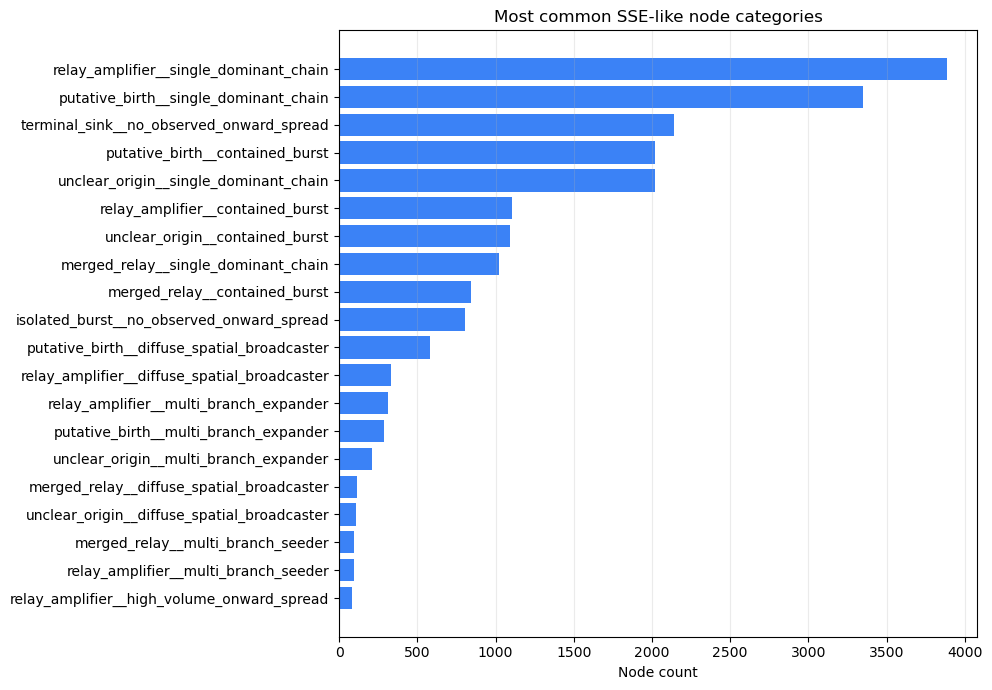

In [12]:
plot_counts = category_counts.query("sse_category != 'not_sse_like'").head(20)

if plot_counts.empty:
    print("No SSE-like candidate categories to plot.")
else:
    fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_counts))))
    ax.barh(plot_counts["sse_category"], plot_counts["n_nodes"], color="#3B82F6")
    ax.invert_yaxis()
    ax.set_xlabel("Node count")
    ax.set_ylabel("")
    ax.set_title("Most common SSE-like node categories")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

## Objects Produced

The main in-memory outputs are:

- `cluster_table`: one row per node-cluster.
- `edge_table`: directed adjacent-window transition edges with shared-sequence weights.
- `meta_summary`: weakly connected component summaries.
- `weekly_growth`: weekly meta-cluster growth diagnostics.
- `node_stats`: node-level metrics, SSE candidate flags, categories, and censoring notes.
- `candidate_review`: ranked candidate node table for inspection.
- `G_raw`: directed adjacent-window cluster transition network.

The companion file `sse_categorise.md` defines the category labels and their intended interpretation.


In [13]:
import gzip
import pickle

OUTPUT_DIR = PROJECT_ROOT / "sse_detection" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

tables_to_save = {
    "cluster_table": cluster_table,
    "edge_table": edge_table,
    "meta_summary": meta_summary,
    "weekly_growth": weekly_growth,
    "node_stats": node_stats,
    "candidate_review": candidate_review,
}

saved_outputs = []
for name, table in tables_to_save.items():
    path = OUTPUT_DIR / f"{name}.parquet"
    table.to_parquet(path, index=False)
    saved_outputs.append(
        {
            "object": name,
            "format": "parquet",
            "n_rows": len(table),
            "n_columns": len(table.columns),
            "n_nodes": None,
            "n_edges": None,
            "path": str(path.relative_to(PROJECT_ROOT)),
        }
    )

sse_network = G_raw.copy()
nx.set_node_attributes(sse_network, node_stats.set_index("cluster_id").to_dict("index"))

edge_attr_cols = [col for col in edge_table.columns if col not in {"source", "target"}]
edge_attrs = {
    (row["source"], row["target"]): {col: row[col] for col in edge_attr_cols}
    for row in edge_table.to_dict("records")
}
nx.set_edge_attributes(sse_network, edge_attrs)

network_path = OUTPUT_DIR / "sse_transition_network.gpickle.gz"
with gzip.open(network_path, "wb") as f:
    pickle.dump(sse_network, f, protocol=pickle.HIGHEST_PROTOCOL)

saved_outputs.append(
    {
        "object": "sse_transition_network",
        "format": "gpickle.gz",
        "n_rows": None,
        "n_columns": None,
        "n_nodes": sse_network.number_of_nodes(),
        "n_edges": sse_network.number_of_edges(),
        "path": str(network_path.relative_to(PROJECT_ROOT)),
    }
)

export_manifest = pd.DataFrame(saved_outputs)
export_manifest.to_parquet(OUTPUT_DIR / "export_manifest.parquet", index=False)
display(export_manifest)

,object,format,n_rows,n_columns,n_nodes,n_edges,path
0,cluster_table,parquet,193160.0,47.0,NaN,NaN,sse_detection/outputs/cluster_table.parquet
1,edge_table,parquet,148184.0,7.0,NaN,NaN,sse_detection/outputs/edge_table.parquet
2,meta_summary,parquet,51773.0,15.0,NaN,NaN,sse_detection/outputs/meta_summary.parquet
3,weekly_growth,parquet,7036096.0,8.0,NaN,NaN,sse_detection/outputs/weekly_growth.parquet
4,node_stats,parquet,193160.0,134.0,NaN,NaN,sse_detection/outputs/node_stats.parquet
5,candidate_review,parquet,20767.0,22.0,NaN,NaN,sse_detection/outputs/candidate_review.parquet
6,sse_transition_network,gpickle.gz,NaN,NaN,193160.0,148184.0,sse_detection/outputs/sse_transition_network.g...
